# Air Quality Monitoring Station Clustering

**Objective:** Group monitoring stations by pollutant mix, traffic influence, temperature, humidity, and wind conditions.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["pm25", "pm10", "no2", "ozone", "humidity_pct", "wind_kph"]
PROFILE_CENTERS = {
  "traffic_core": [
    78,
    116,
    64,
    24,
    55,
    8
  ],
  "industrial": [
    96,
    148,
    52,
    31,
    62,
    10
  ],
  "suburban": [
    34,
    58,
    25,
    47,
    58,
    14
  ],
  "coastal_clean": [
    18,
    31,
    13,
    55,
    72,
    24
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,pm25,pm10,no2,ozone,humidity_pct,wind_kph,generator_profile
0,43.563,48.086,23.154,44.104,53.065,12.491,suburban
1,72.897,120.964,62.789,24.789,56.991,9.057,traffic_core
2,35.674,54.401,21.045,43.500,57.683,15.632,suburban
3,96.058,154.635,58.060,36.107,63.920,10.590,industrial
4,81.675,109.812,61.366,27.270,49.277,6.070,traffic_core


,count,mean,std,min,25%,50%,75%,max
pm25,492.0,56.275,32.591,14.221,24.927,43.378,85.998,126.517
pm10,492.0,88.029,47.216,21.502,46.011,82.252,129.089,182.186
no2,500.0,38.360,20.891,9.902,18.504,35.248,57.035,82.592
ozone,500.0,39.376,13.145,17.845,27.176,37.688,50.994,69.491
humidity_pct,500.0,61.679,8.964,41.745,55.256,60.265,67.117,90.522
wind_kph,500.0,14.000,6.468,5.947,8.691,11.452,17.986,29.737


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=3 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.5451,0.7330
1,3,0.5530,0.6254
2,4,0.4795,0.7938
3,5,0.4309,0.9217
4,6,0.3841,1.0379


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.5530,0.6254
1,Agglomerative,0.5463,0.6269


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 0.6906


,records,pm25,pm10,no2,ozone,humidity_pct,wind_kph
cluster,,,,,,,
0,250,87.037,131.588,57.858,27.581,58.460,8.970
1,120,18.175,30.869,12.961,55.595,73.011,24.336
2,130,32.701,56.606,24.306,47.084,57.409,14.133


cluster,0,1,2,All
generator_profile,,,,
coastal_clean,0,120,5,125
industrial,125,0,0,125
suburban,0,0,125,125
traffic_core,125,0,0,125
All,250,120,130,500


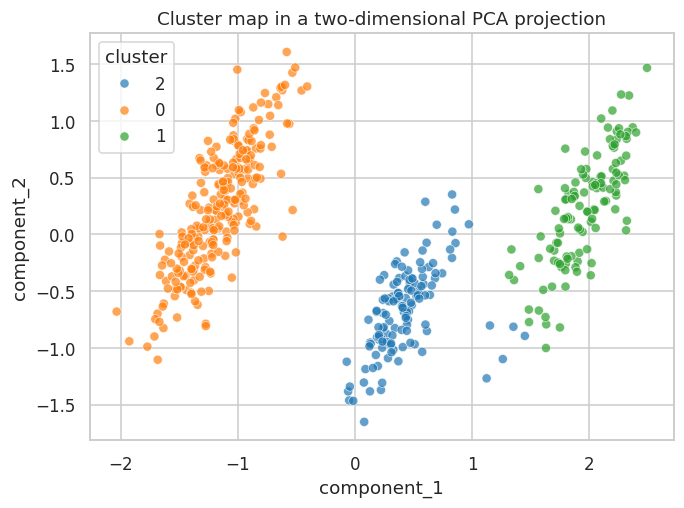

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,pm25,pm10,no2,ozone,humidity_pct,wind_kph,predicted_cluster
0,43.378,82.252,35.248,37.688,60.265,11.452,2


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
